In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned data
df = pd.read_csv('../data/superstore_clean.csv')

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

print("Data loaded! Shape:", df.shape)

Data loaded! Shape: (9977, 15)


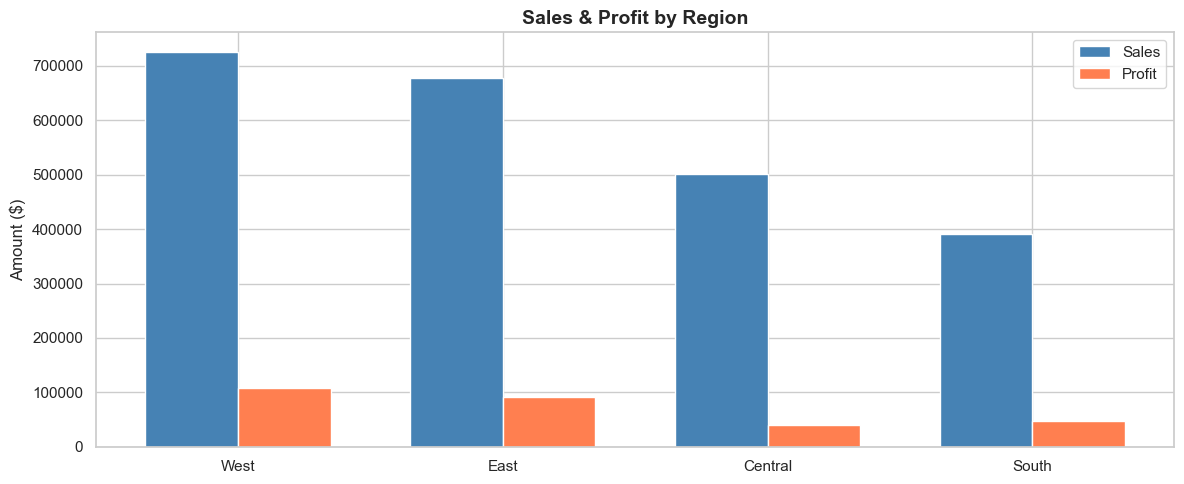

Chart saved!


In [3]:
region_data = df.groupby('Region')[['Sales', 'Profit']].sum().round(2).reset_index()
region_data = region_data.sort_values('Sales', ascending=False)

fig, ax = plt.subplots()
x = range(len(region_data))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], region_data['Sales'], width, label='Sales', color='steelblue')
bars2 = ax.bar([i + width/2 for i in x], region_data['Profit'], width, label='Profit', color='coral')

ax.set_title('Sales & Profit by Region', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(region_data['Region'])
ax.set_ylabel('Amount ($)')
ax.legend()

plt.tight_layout()
plt.savefig('../dashboard/screenshots/01_sales_by_region.png', dpi=150)
plt.show()
print("Chart saved!")

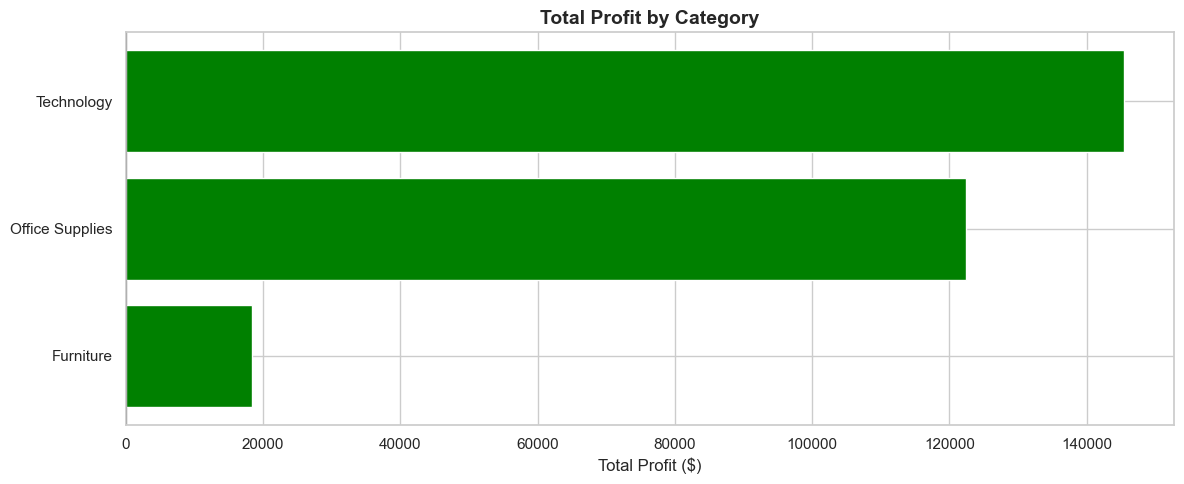

Chart saved!


In [4]:
cat_data = df.groupby('Category')['Profit'].sum().round(2).reset_index()
cat_data = cat_data.sort_values('Profit')

colors = ['red' if x < 0 else 'green' for x in cat_data['Profit']]

plt.figure()
plt.barh(cat_data['Category'], cat_data['Profit'], color=colors)
plt.title('Total Profit by Category', fontsize=14, fontweight='bold')
plt.xlabel('Total Profit ($)')
plt.axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('../dashboard/screenshots/02_profit_by_category.png', dpi=150)
plt.show()
print("Chart saved!")

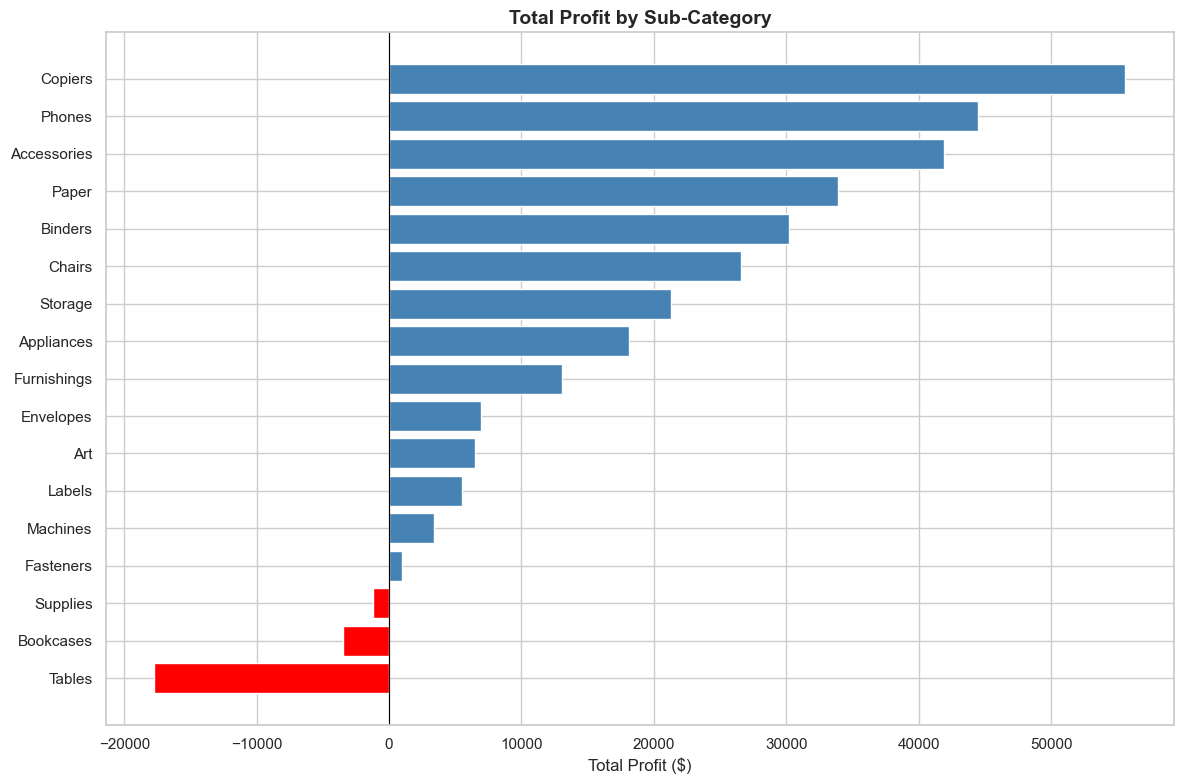

Chart saved!


In [7]:
sub_data = df.groupby('Sub-Category')['Profit'].sum().round(2).reset_index()
sub_data = sub_data.sort_values('Profit')

colors = ['red' if x < 0 else 'steelblue' for x in sub_data['Profit']]

plt.figure(figsize=(12, 8))
plt.barh(sub_data['Sub-Category'], sub_data['Profit'], color=colors)
plt.title('Total Profit by Sub-Category', fontsize=14, fontweight='bold')
plt.xlabel('Total Profit ($)')
plt.axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('../dashboard/screenshots/03_profit_by_subcategory.png', dpi=150)
plt.show()
print("Chart saved!")

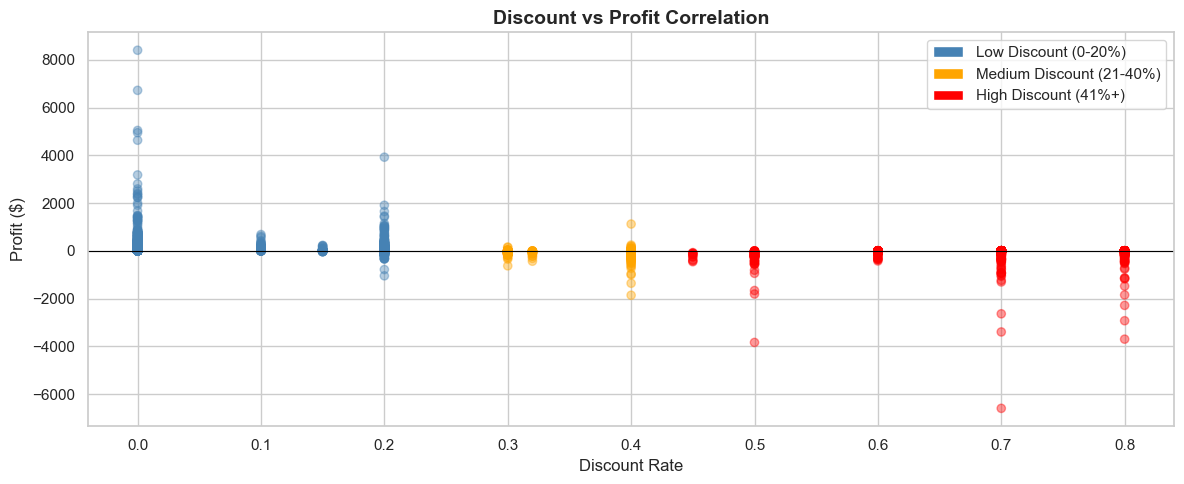

Chart saved!


In [8]:
plt.figure()
colors = df['Discount'].apply(lambda x: 'red' if x > 0.4 else ('orange' if x > 0.2 else 'steelblue'))

plt.scatter(df['Discount'], df['Profit'], c=colors, alpha=0.4)
plt.title('Discount vs Profit Correlation', fontsize=14, fontweight='bold')
plt.xlabel('Discount Rate')
plt.ylabel('Profit ($)')
plt.axhline(y=0, color='black', linewidth=0.8)

# Add legend manually
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', label='Low Discount (0-20%)'),
    Patch(facecolor='orange', label='Medium Discount (21-40%)'),
    Patch(facecolor='red', label='High Discount (41%+)')
]
plt.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig('../dashboard/screenshots/04_discount_vs_profit.png', dpi=150)
plt.show()
print("Chart saved!")

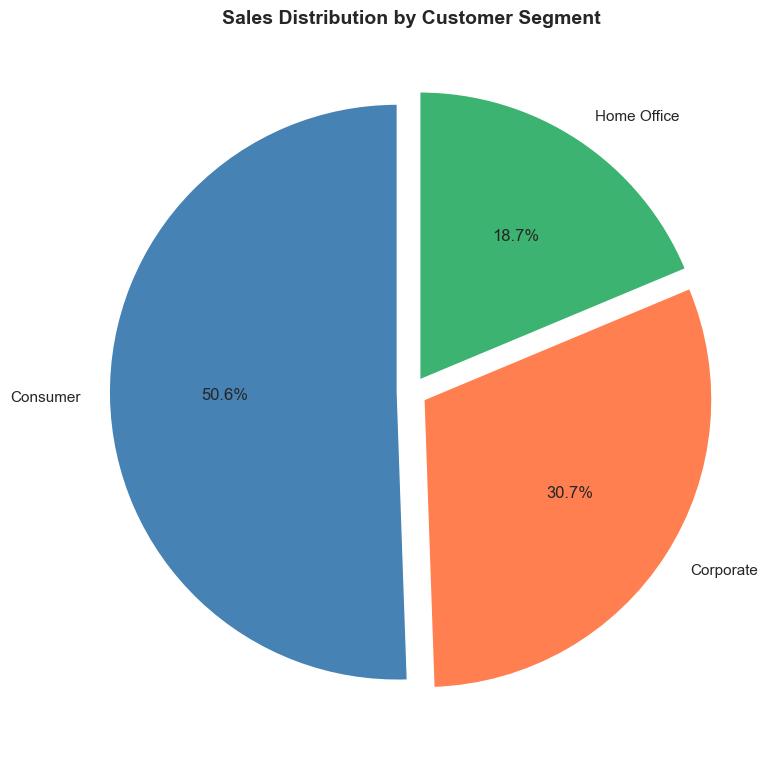

Chart saved!


In [9]:
seg_data = df.groupby('Segment')['Sales'].sum().round(2)

plt.figure(figsize=(8, 8))
plt.pie(seg_data, 
        labels=seg_data.index, 
        autopct='%1.1f%%',
        colors=['steelblue', 'coral', 'mediumseagreen'],
        startangle=90,
        explode=(0.05, 0.05, 0.05))

plt.title('Sales Distribution by Customer Segment', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../dashboard/screenshots/05_sales_by_segment.png', dpi=150)
plt.show()
print("Chart saved!")

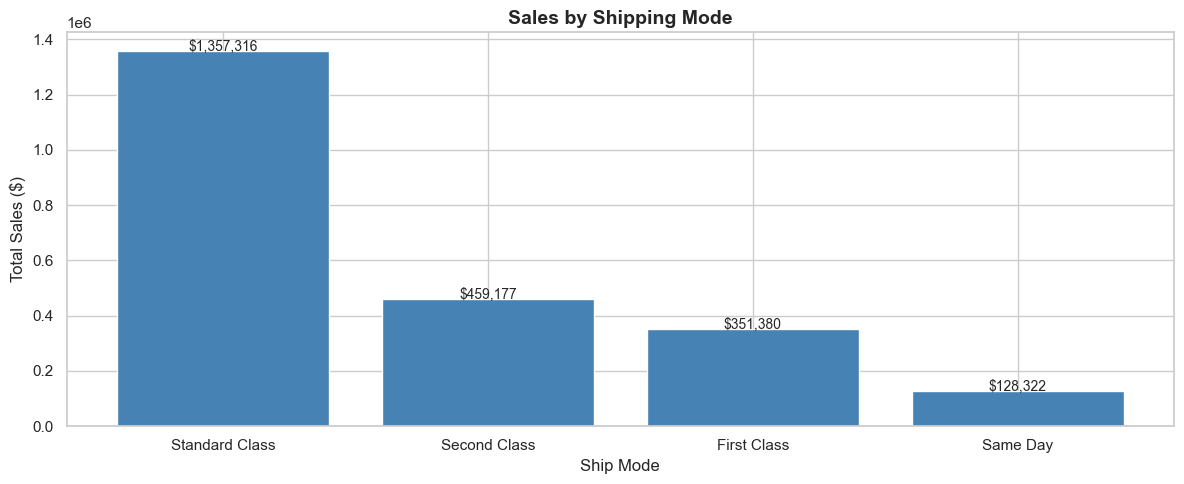

Chart saved!


In [13]:
ship_data = df.groupby('Ship Mode')['Sales'].sum().round(2).reset_index()
ship_data = ship_data.sort_values('Sales', ascending=False)

plt.figure()
bars = plt.bar(ship_data['Ship Mode'], ship_data['Sales'], color='steelblue')

# Add value labels on top of bars
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 1000,
             f'${bar.get_height():,.0f}', 
             ha='center', fontsize=10)

plt.title('Sales by Shipping Mode', fontsize=14, fontweight='bold')
plt.xlabel('Ship Mode')
plt.ylabel('Total Sales ($)')

plt.tight_layout()
plt.savefig('../dashboard/screenshots/06_sales_by_shipmode.png', dpi=150)
plt.show()
print("Chart saved!")

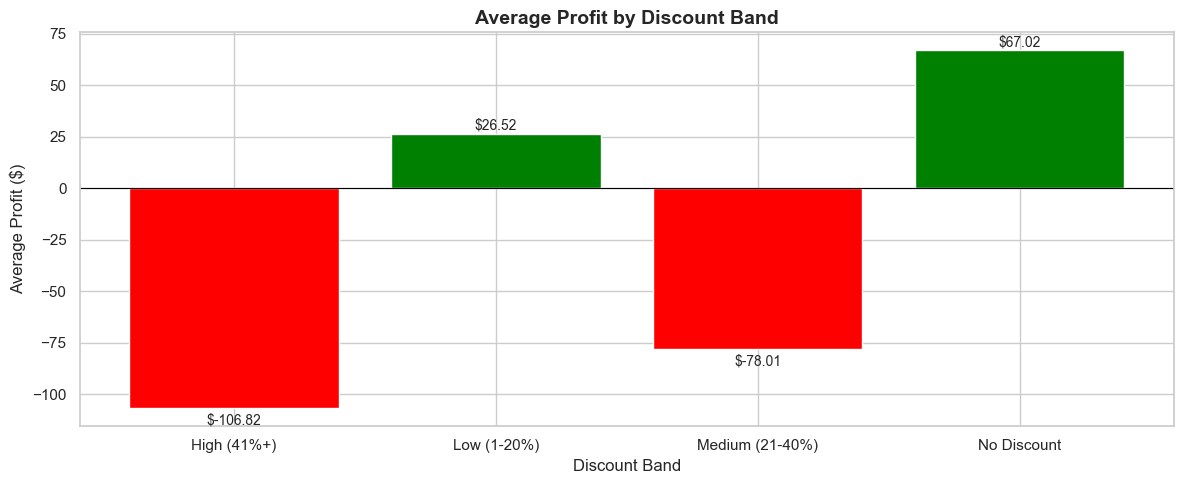

Chart saved!


In [14]:
disc_data = df.groupby('Discount_Band')['Profit'].mean().round(2).reset_index()

colors = ['green' if x > 0 else 'red' for x in disc_data['Profit']]

plt.figure()
bars = plt.bar(disc_data['Discount_Band'], disc_data['Profit'], color=colors)

# Add value labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             yval + (2 if yval > 0 else -8),
             f'${yval}',
             ha='center', fontsize=10)

plt.title('Average Profit by Discount Band', fontsize=14, fontweight='bold')
plt.xlabel('Discount Band')
plt.ylabel('Average Profit ($)')
plt.axhline(y=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('../dashboard/screenshots/07_profit_by_discount_band.png', dpi=150)
plt.show()
print("Chart saved!")